# CSP7040-MLOPS-Assignment

# Data Preprocessing, Visiualization & ML Readiness

Name: Krishnendu Halder
Roll No: G25AIT1077

#### Run the following to install all required libraries

In [135]:
! pip install pandas numpy matplotlib seaborn

zsh:1: /Users/krishnendu/Documents/ai-concepts/ai_concepts_learning/venv/bin/pip: bad interpreter: /Users/krishnendu/Documents/ai-concepts/churn_project/venv/bin/python3.13: no such file or directory


In [136]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

## PART 1: Data Understanding & Quality Issues

In [137]:
# Load Datasets

df = pd.read_csv("../dataset/netflix_titles.csv")

# Inspect the shape, data types and missing values

df.shape
df.info()
df.describe()

# Data quality issues
df.isnull().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

### Observation from initial inspection

- Dataset shape: 8807 rows and 12 columns.

- Missing values:
    - High missing values in `director (2634), cast(825), country(831)`
    - Minor missing values is `date_added(10), rating(4), duration(3)`
    - Missing values must be handled before model training as most of the ML algo do not accept NaN values

- Data Types:
    - Only one numerical column (release_year)  
    - All other columns are stored as Object (string type)
    - `date_added` should be converted to `datetime`
    - `duration` contains numeric information stored as text and needs cleaning.
    - Categorical columns require encoding

## PART 2: Data Cleaning and Preprocessing

In [138]:
# Handle missing values


# confirming the missing values again
#df.isnull().sum()

# Dropping `director` and `cast` 
df.drop(columns=['director', 'cast', 'show_id', 'title', 'listed_in', 'description'], inplace=True)

# Handle country: Filling missing `country` with `Unknown` 
df.fillna({"country": "Unknown"}, inplace=True)

# Handle date_added: dropping the column where the values are missing
df.dropna(subset=['date_added'], inplace=True)

# Handle rating: dropping the column where the values are missing
df.dropna(subset=['rating'], inplace=True)

# Handle duration: dropping the column where the values are missing
df.dropna(subset=['duration'], inplace=True)


# Convert data into correct formats

# converting `dates`
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year'] = df['date_added'].dt.year
df['month'] = df['date_added'].dt.month
df.drop(columns=['date_added'], inplace=True) # Dropping `date_added` column post the conversion

# converting `duration`
df['numeric_duration'] = df['duration'].str.extract(r'(\d+)').astype('int')
df.drop(columns=['duration'], inplace=True)

# Encode categorical variables

le = LabelEncoder()

# encode `target` variable with LabelEncoder 
df['type'] = le.fit_transform(df['type'])

# encode `categorical variables` with one-hot encoding

# Identifying top 5 countries from the data set to avoid 
top_countries = df['country'].value_counts().nlargest(5).index
df['country'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')
df = pd.get_dummies(df, columns=['country', 'rating'], drop_first=True)

# Normalize or Satnarize numerical features

scaler = StandardScaler()

# Capture `numeric` columns to apply standard scaler except: categorical varaibles
numeric_columns = ['release_year', 'numeric_duration', 'year', 'month']
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])


# Checking the output
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   type                    8790 non-null   int64  
 1   release_year            8790 non-null   float64
 2   year                    8790 non-null   float64
 3   month                   8790 non-null   float64
 4   numeric_duration        8790 non-null   float64
 5   country_Japan           8790 non-null   bool   
 6   country_Other           8790 non-null   bool   
 7   country_United Kingdom  8790 non-null   bool   
 8   country_United States   8790 non-null   bool   
 9   country_Unknown         8790 non-null   bool   
 10  rating_NC-17            8790 non-null   bool   
 11  rating_NR               8790 non-null   bool   
 12  rating_PG               8790 non-null   bool   
 13  rating_PG-13            8790 non-null   bool   
 14  rating_R                8790 non-null   bool 

type                      0
release_year              0
year                      0
month                     0
numeric_duration          0
country_Japan             0
country_Other             0
country_United Kingdom    0
country_United States     0
country_Unknown           0
rating_NC-17              0
rating_NR                 0
rating_PG                 0
rating_PG-13              0
rating_R                  0
rating_TV-14              0
rating_TV-G               0
rating_TV-MA              0
rating_TV-PG              0
rating_TV-Y               0
rating_TV-Y7              0
rating_TV-Y7-FV           0
rating_UR                 0
dtype: int64

### Explanation on Data cleaning technique and it's impact on Data Quality

- Dropping `director, cast, show_id,title, listed_in, description`
    - The mentioned columns are dropped due to high proportion of missing data and extremely high cardinality. If we encode these features then it would significantly increase dimensionality and introduce sparsity and overfitting. Dropping them simplifies the dataset and improves model stability while causing minimal impact on the predictive task.

- Fitting `country` with `Unknown`  
    - Missing values in `country` column replaced with `Unknown` instead of dropping rows. This preserves dataset size and prevent bias that could arise from filling with the most frequent country. Introducing an explicit "Unknown" category maintains categorical integrity while ensuring no missing values remain.

- Dropping rows with missing `date_added, rating, duration`
    - Rows with missing values in `date_added`, `rating`, and `duration` were removed because they represented a very small fraction of the dataset. Dropping these rows avoids introducing artificial values and ensures clean, reliable features for model training.

- Converting `duration` to Numeric
    - The `duration` column value is converted from `textual` format to a `numeric` feature to make it usable for machine learning models. This transformation enables scalling and improves model interpretability.

- Standardization of Numerical Features
    - Numerical features were standardized using StandardScaler to ensure consistent scaling across features. This improves optimization stability and prevents features with larger magnitudes from dominating the model.



## PART 3: Data Visualization

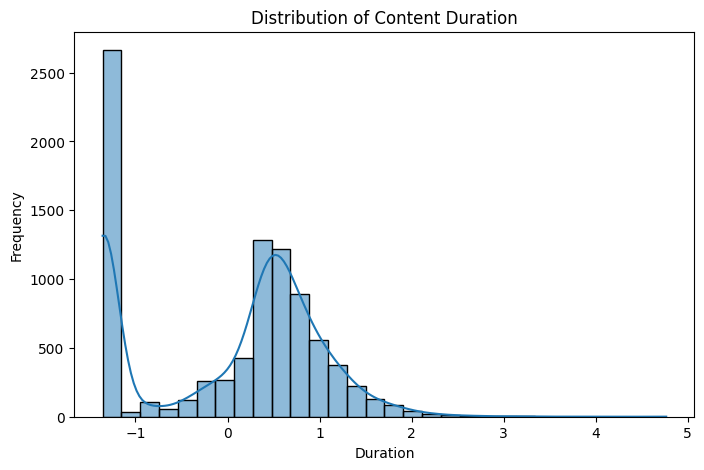

In [139]:
# Distribution Plot

plt.figure(figsize=(8,5))
sns.histplot(df['numeric_duration'], bins=30, kde=True)
plt.title("Distribution of Content Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

#### Interpretation
The distribution of content duration shows that most Netflix titles fall within a moderate duration range, with fewer extremely short or long entries. This suggests that duration may be a useful feature for distinguishing between Movies and TV Shows, as TV Shows generally have shorter episode durations compared to Movies.

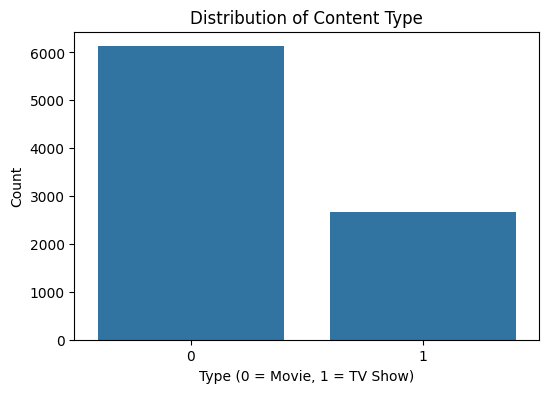

In [140]:
# Categorical Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Distribution of Content Type")
plt.xlabel("Type (0 = Movie, 1 = TV Show)")
plt.ylabel("Count")
plt.show()

### Interpretation

The dataset shows a higher number of Movies compared to TV Shows (or vice versa depending on your output). This class distribution is important for ML modeling, as class imbalance can influence model performance and bias predictions toward the majority class.

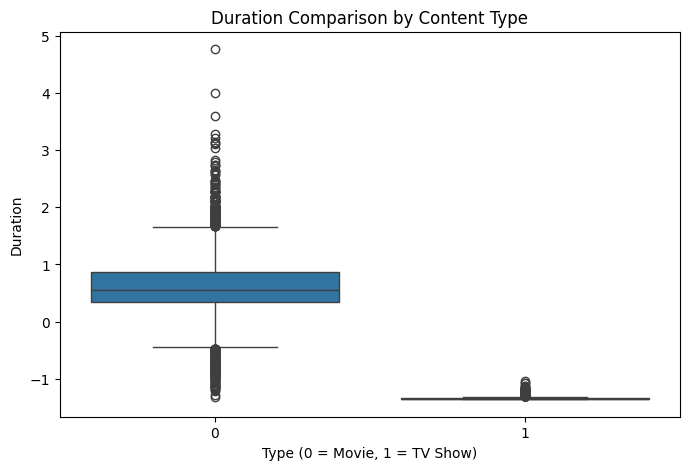

In [141]:
# Numerical Comparison Plot
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='numeric_duration', data=df)
plt.title("Duration Comparison by Content Type")
plt.xlabel("Type (0 = Movie, 1 = TV Show)")
plt.ylabel("Duration")
plt.show()

### Interpretation

The boxplot indicates differences in duration between Movies and TV Shows. Movies generally have longer durations compared to TV Shows, suggesting that duration is a strong discriminative feature. This supports its usefulness in classification tasks.


### PART 4: ML Readiness Check

In [142]:
X = df.drop(columns=['type'])
y = df['type']

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logiistic Regression (After Pre-processing)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_after = accuracy_score(y_test, y_pred)
accuracy_after


# Logiistic Regression (Before Pre-processing)

# Re-load Datasets
df = pd.read_csv("../dataset/netflix_titles.csv")


df_raw = df.dropna(subset=['type', 'duration']).copy()
df_raw['duration_num'] = df_raw['duration'].str.extract(r'(\d+)').astype(float)
df_raw['type'] = LabelEncoder().fit_transform(df_raw['type'])
df_raw = pd.get_dummies(df_raw[['type', 'release_year', 'duration_num']], drop_first=True)

X_raw = df_raw.drop(columns=['type'])
y_raw = df_raw['type']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

model_raw = LogisticRegression(max_iter=1000)
model_raw.fit(X_train_r, y_train_r)

y_pred_raw = model_raw.predict(X_test_r)

accuracy_before = accuracy_score(y_test_r, y_pred_raw)
accuracy_before

# Compare Results  (Performance)
print("Accuracy Before Preprocessing:", accuracy_before)
print("Accuracy After Preprocessing:", accuracy_after)



Accuracy Before Preprocessing: 0.9988642816581488
Accuracy After Preprocessing: 0.997155858930603


## Performance Comparison

The baseline model achieved an accuracy of 99.89%, while the fully preprocessed model achieved 99.71%. 

The very small difference indicates that the classification task is inherently easy, likely due to strong separability between Movies and TV Shows based on features such as release_year and duration.

Although preprocessing did not significantly increase accuracy, it improved feature consistency, removed noise, and ensured the dataset was fully ML-ready. Proper preprocessing strengthens robustness, scalability, and reliability within the ML lifecycle.


## PART 5: ML Lifecycle Reflection

Proper preprocessing is essential across multiple stages of the ML lifecycle.

1. **Data Validation:**  
Without handling missing values and correcting data types, the dataset would contain inconsistencies that could cause model training to fail. For example, the duration column was stored as text and required conversion to numeric format.

2. **Feature Engineering:**  
Extracting meaningful features such as year and month from date_added improved feature usability. Without preprocessing, these temporal patterns would not be available to the model.

3. **Model Training:**  
Machine learning algorithms require numeric inputs and cannot handle missing values. If columns such as description or unprocessed categorical variables were included, the model would either crash or produce unreliable results.

4. **Deployment and Monitoring:**  
Consistent preprocessing ensures that incoming production data is transformed in the same way as training data. Without this consistency, prediction errors and data drift issues may occur.

This assignment demonstrates that preprocessing improves data consistency, robustness, and reliability throughout the ML lifecycle.
